# Slot Model

1. Define per-slot vocabularies and construct per-slot distance matrices.
2. Configure the compositional data generator that uses these distances to create labels.
3. Build a compositional (slot) model.
4. Train once and validate.
5. Plot results.


In [34]:
# Imports
import torch, numpy as np
import matplotlib.pyplot as plt
from typing import Tuple
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

# Local src
import sys, os
sys.path.append(os.path.abspath(os.path.join('..','src')))
from MillerDataGen import CompositionalDataGenerator, CompositionalDataGeneratorConfig
from MillerTest import CompositionalModel, CompositionalModelConfig
from MillerTrainer import MillerTrainer, TrainerConfig

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


## Define per-slot vocabularies and distance matrices
We use two slots (e.g., color and shape) with vocab sizes `(8, 8)`. For clarity, we create ring/circular distance matrices for both slots, where nearby values are closer and opposite values are farthest.


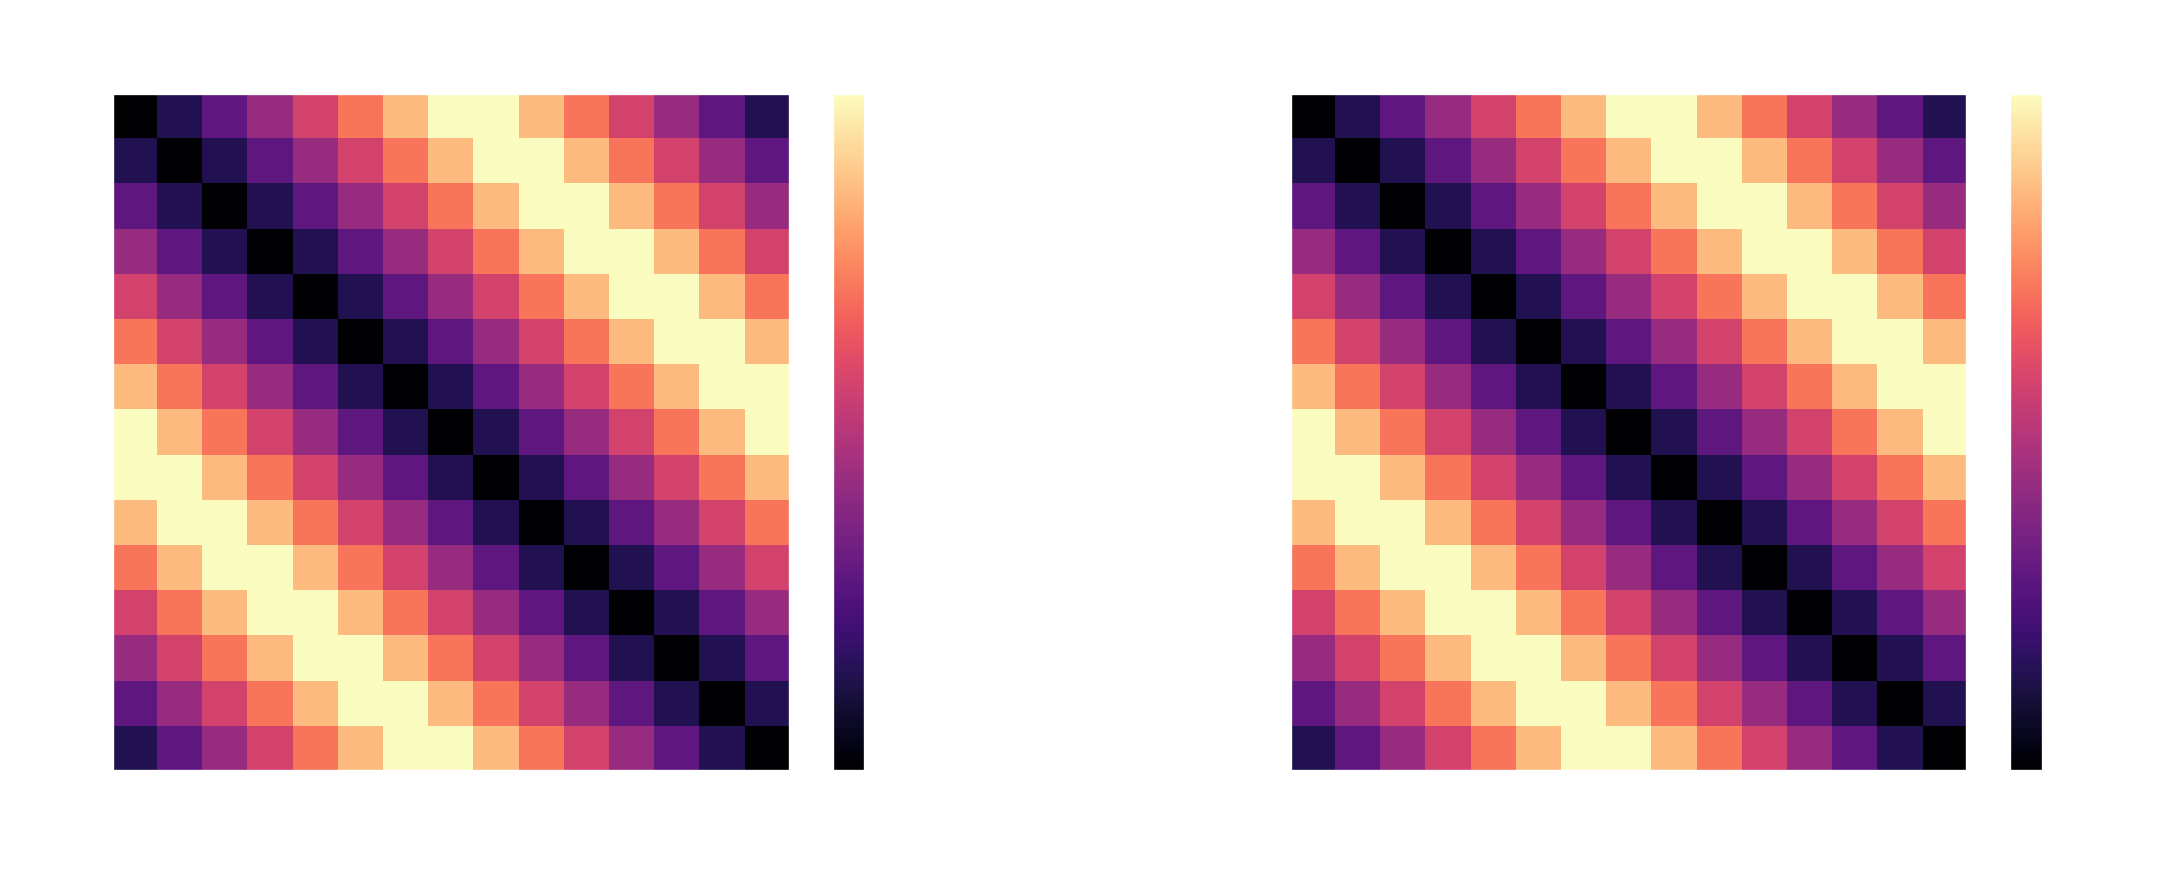

In [104]:
# Construct per-slot distance matrices with explanatory comments
V_A, V_B = 15, 15  # vocab sizes per slot

# Both slots: circular/ring
def ring(V: int):
    idx = torch.arange(V).unsqueeze(0)
    circ = torch.minimum((idx - idx.T).abs(), V - (idx - idx.T).abs())
    return (circ / circ.max()).to(torch.float32)

D_A = ring(V_A)
D_B = ring(V_B)

slot_metric_matrices = (D_A, D_B)

# Quick visualization
fig, axes = plt.subplots(1, 2, figsize=(8,3), facecolor='none', dpi=300)
fig.patch.set_alpha(0)
fig.patch.set_facecolor('none')
im0 = axes[0].imshow(D_A.numpy(), cmap='magma')
im1 = axes[1].imshow(D_B.numpy(), cmap='magma')
axes[0].set_title('Slot A distances', color='white')
axes[1].set_title('Slot B distances', color='white')
# Colorbars
cbar0 = plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
cbar1 = plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
# White axes/spines/ticks and transparent axes background
for ax_sub in axes:
    ax_sub.set_facecolor('none')
    for spine in ax_sub.spines.values():
        spine.set_color('white')
    ax_sub.tick_params(colors='white')
# Style colorbars to white and transparent
for cb in (cbar0, cbar1):
    cb.outline.set_edgecolor('white')
    cb.ax.set_facecolor('none')
    cb.ax.yaxis.set_tick_params(color='white')
    for tick in cb.ax.get_yticklabels():
        tick.set_color('white')
plt.tight_layout(); plt.show()


## Configure generator and slot model
We use the compositional generator and model from `Toy_model/src`.
- The generator builds sequences of composites and uses the per-slot distance matrices to create similarity labels, aggregating across slots using `min` (i.e., match if any slot matches closely).
- The model learns per-slot linear embeddings, and similarity decisions are computed as max over per-slot similarities between context and probe.


In [36]:
# Data generator configuration
num_slots = 2
vocab_sizes: Tuple[int, ...] = (V_A, V_B)
sequence_len = 3
batch_size = 64
num_samples = 2048

# Choose aggregation across slots for labeling: 'min'|'max'|'L1'|'L2'
distance_aggregation = 'min'

gen_cfg = CompositionalDataGeneratorConfig(
    num_slots=num_slots,
    vocab_sizes=vocab_sizes,
    sequence_len=sequence_len,
    batch_size=batch_size,
    slot_metric_matrices=slot_metric_matrices,
    seed=SEED,
    num_samples=num_samples,
    distance_aggregation=distance_aggregation,
)

data_gen = CompositionalDataGenerator(gen_cfg)

# Model configuration
feature_dim = 16
model_cfg = CompositionalModelConfig(
    input_dim=sum(vocab_sizes),
    feature_dim=feature_dim,
    sequence_len=sequence_len,
    vocab_sizes=vocab_sizes,
)

model = CompositionalModel(model_cfg)


## Train and validate
We train for a small number of epochs for demonstration. The trainer reports:
- Similarity (generalization) score on the generator's validation routine.
- Identification score.
- Loss curves for similarity and reconstruction.


In [37]:
# Trainer configuration
trainer_cfg = TrainerConfig()
# Set minimal options for a quick run
trainer_cfg.num_epochs = 300
trainer_cfg.learning_rate = 1e-3
trainer_cfg.weight_decay = 1e-5
trainer_cfg.patience = 10
trainer_cfg.min_lr = 1e-6

if not hasattr(trainer_cfg, 'lambda_sim'):
    trainer_cfg.lambda_sim = 1.0
if not hasattr(trainer_cfg, 'lambda_rec'):
    trainer_cfg.lambda_rec = 1.0

# Ensure evaluator gets a device on the generator config
data_gen.config.device = trainer_cfg.device

trainer = MillerTrainer(model, data_gen, trainer_cfg)
# Option B: compute embeddings during training
history, epoch_embs = trainer.train(verbose=True, printevery=50, compute_embeddings=True)
val_g = history['similarity_scores'][-1]
val_i = history['identification_scores'][-1]
print(f"Final Validation - G: {val_g:.3f}, I: {val_i:.3f}")


Epoch 0:
  Train - Sim Loss: 4.1796, Reconstruction Loss: 0.0313
  Val - G Score: 0.5257, I Score: 0.8813
Epoch 50:
  Train - Sim Loss: 1.4492, Reconstruction Loss: 0.0318
  Val - G Score: 0.7288, I Score: 0.9233
Epoch 100:
  Train - Sim Loss: 1.1591, Reconstruction Loss: 0.0316
  Val - G Score: 0.7286, I Score: 0.9283
Epoch 150:
  Train - Sim Loss: 1.0935, Reconstruction Loss: 0.0316
  Val - G Score: 0.7197, I Score: 0.9234
Epoch 200:
  Train - Sim Loss: 0.9979, Reconstruction Loss: 0.0315
  Val - G Score: 0.7172, I Score: 0.9280
Epoch 250:
  Train - Sim Loss: 1.1002, Reconstruction Loss: 0.0315
  Val - G Score: 0.7280, I Score: 0.9292
Final Validation - G: 0.726, I: 0.929


## Plot results
We visualize validation scores across epochs and the training losses to confirm learning behavior.


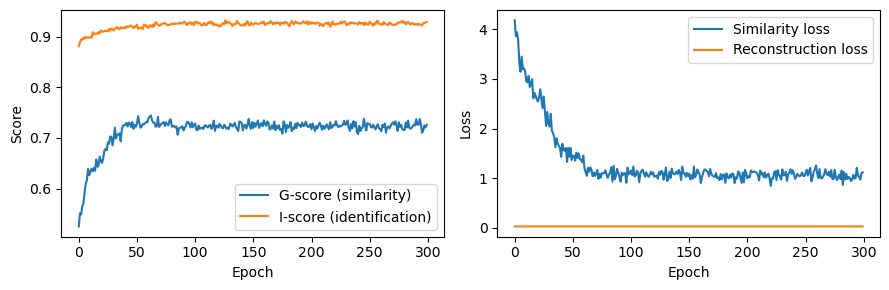

In [38]:
epochs = np.arange(len(history['similarity_scores']))

fig, axes = plt.subplots(1, 2, figsize=(9,3))
axes[0].plot(epochs, history['similarity_scores'], label='G-score (similarity)')
axes[0].plot(epochs, history['identification_scores'], label='I-score (identification)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Score'); axes[0].legend()

axes[1].plot(epochs, history['similarity_losses'], label='Similarity loss')
axes[1].plot(epochs, history['reconstruction_losses'], label='Reconstruction loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()

plt.tight_layout()
plt.show()


## Sweep number of slots S
We vary the number of slots `S` (keeping per-slot vocab size fixed) and run a single short training for each `S`, recording final validation scores. This shows how performance scales with compositionality depth.


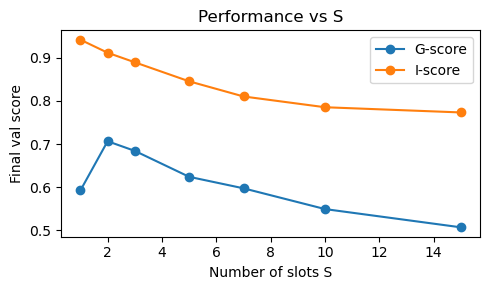

In [120]:
def make_ring(V: int) -> torch.Tensor:
    idx = torch.arange(V).unsqueeze(0)
    circ = torch.minimum((idx - idx.T).abs(), V - (idx - idx.T).abs())
    return (circ / circ.max()).to(torch.float32)

S_values = [1, 2, 3, 5, 7, 10, 15]
V_per_slot = 15
sequence_len = 3
batch_size = 64
num_samples = 1024
feature_dim = 16
agg = 'min'

scores_G, scores_I = [], []
S_histories = {}
for S in S_values:
    vocab_sizes = tuple([V_per_slot] * S)
    slot_metric_matrices = tuple([make_ring(V_per_slot) for _ in range(S)])
    gen_cfg = CompositionalDataGeneratorConfig(
        num_slots=S,
        vocab_sizes=vocab_sizes,
        sequence_len=sequence_len,
        batch_size=batch_size,
        slot_metric_matrices=slot_metric_matrices,
        seed=SEED,
        num_samples=num_samples,
        distance_aggregation=agg,
    )
    data_gen_S = CompositionalDataGenerator(gen_cfg)

    model_cfg_S = CompositionalModelConfig(
        input_dim=sum(vocab_sizes),
        feature_dim=feature_dim,
        sequence_len=sequence_len,
        vocab_sizes=vocab_sizes,
    )
    model_S = CompositionalModel(model_cfg_S)

    # Trainer
    trainer_cfg_S = TrainerConfig()
    trainer_cfg_S.num_epochs = 300
    trainer_cfg_S.learning_rate = 1e-3
    trainer_cfg_S.patience = 10
    trainer_cfg_S.min_lr = 1e-6
    # default loss weights if missing
    if not hasattr(trainer_cfg_S, 'lambda_sim'):
        trainer_cfg_S.lambda_sim = 5.0
    if not hasattr(trainer_cfg_S, 'lambda_rec'):
        trainer_cfg_S.lambda_rec = 1.0
    # ensure evaluator device
    data_gen_S.config.device = trainer_cfg_S.device

    trainer_S = MillerTrainer(model_S, data_gen_S, trainer_cfg_S)
    history_S = trainer_S.train(verbose=False, printevery=50)

    # collect
    S_histories[S] = history_S
    scores_G.append(history_S['similarity_scores'][-1])
    scores_I.append(history_S['identification_scores'][-1])

# Plot final scores vs S
plt.figure(figsize=(5,3))
plt.plot(S_values, scores_G, '-o', label='G-score')
plt.plot(S_values, scores_I, '-o', label='I-score')
plt.xlabel('Number of slots S'); plt.ylabel('Final val score')
plt.title('Performance vs S')
plt.legend(); plt.tight_layout(); plt.show()


/var/folders/qq/vh114g916ydccg5ydgm445n40000gn/T/ipykernel_24770/2681727582.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')


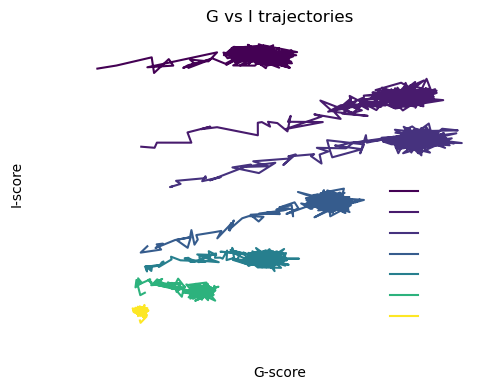

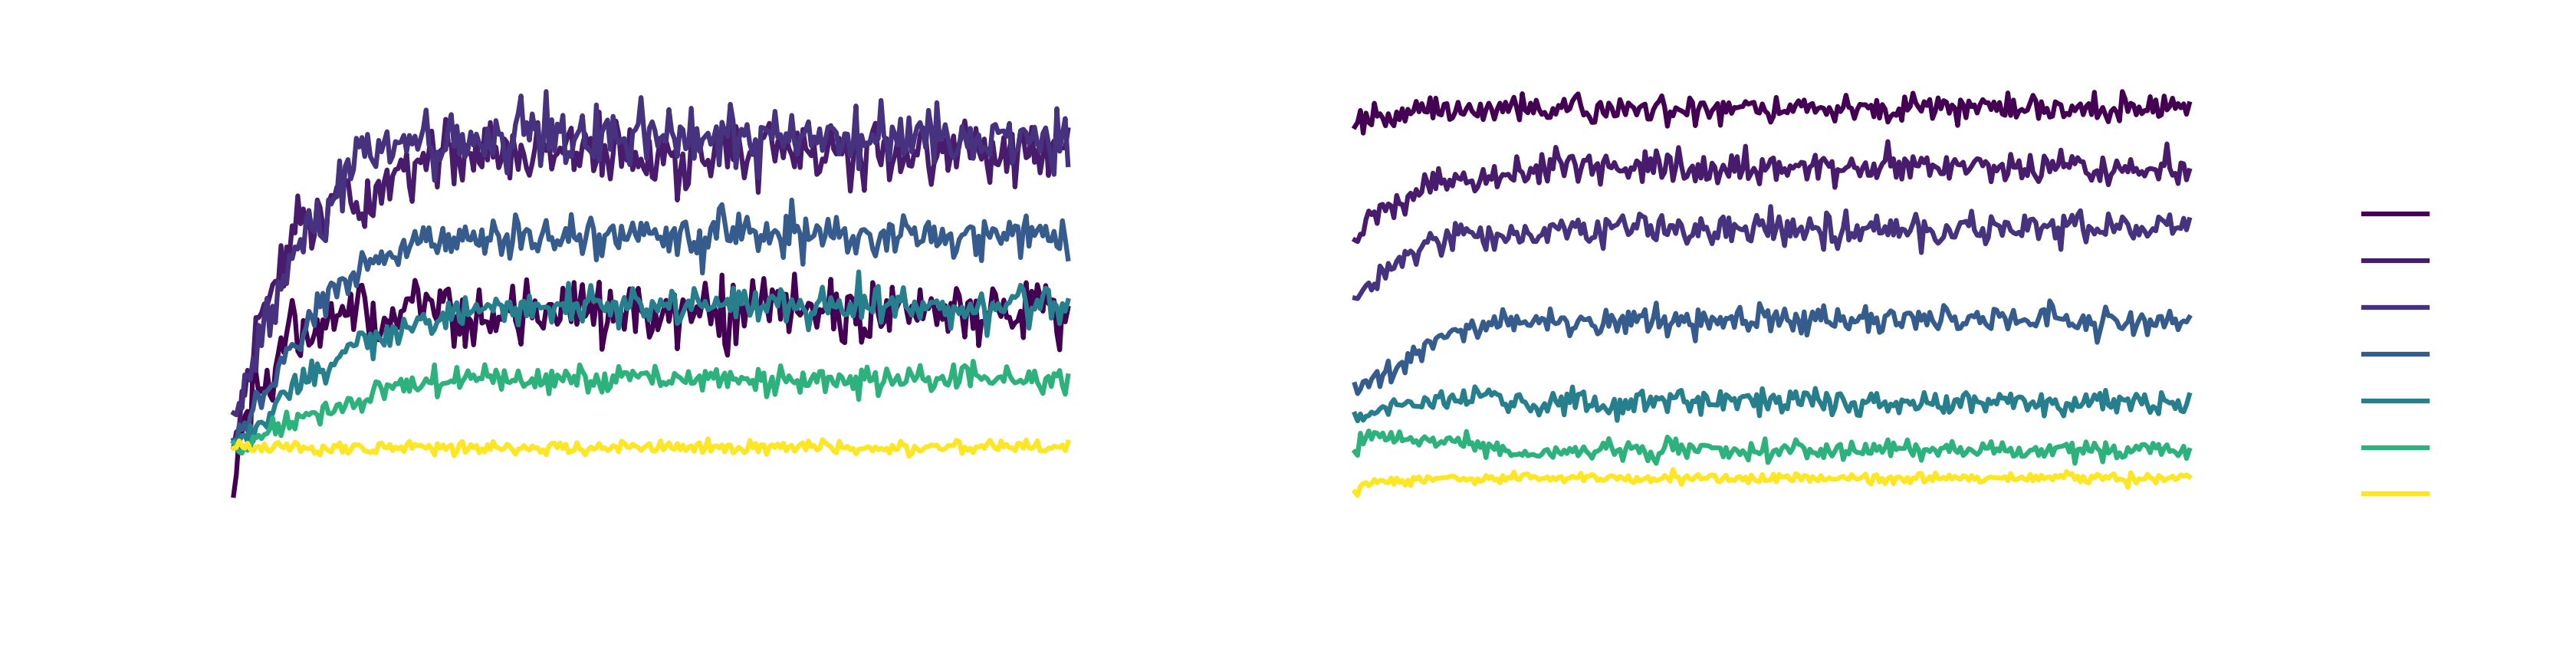

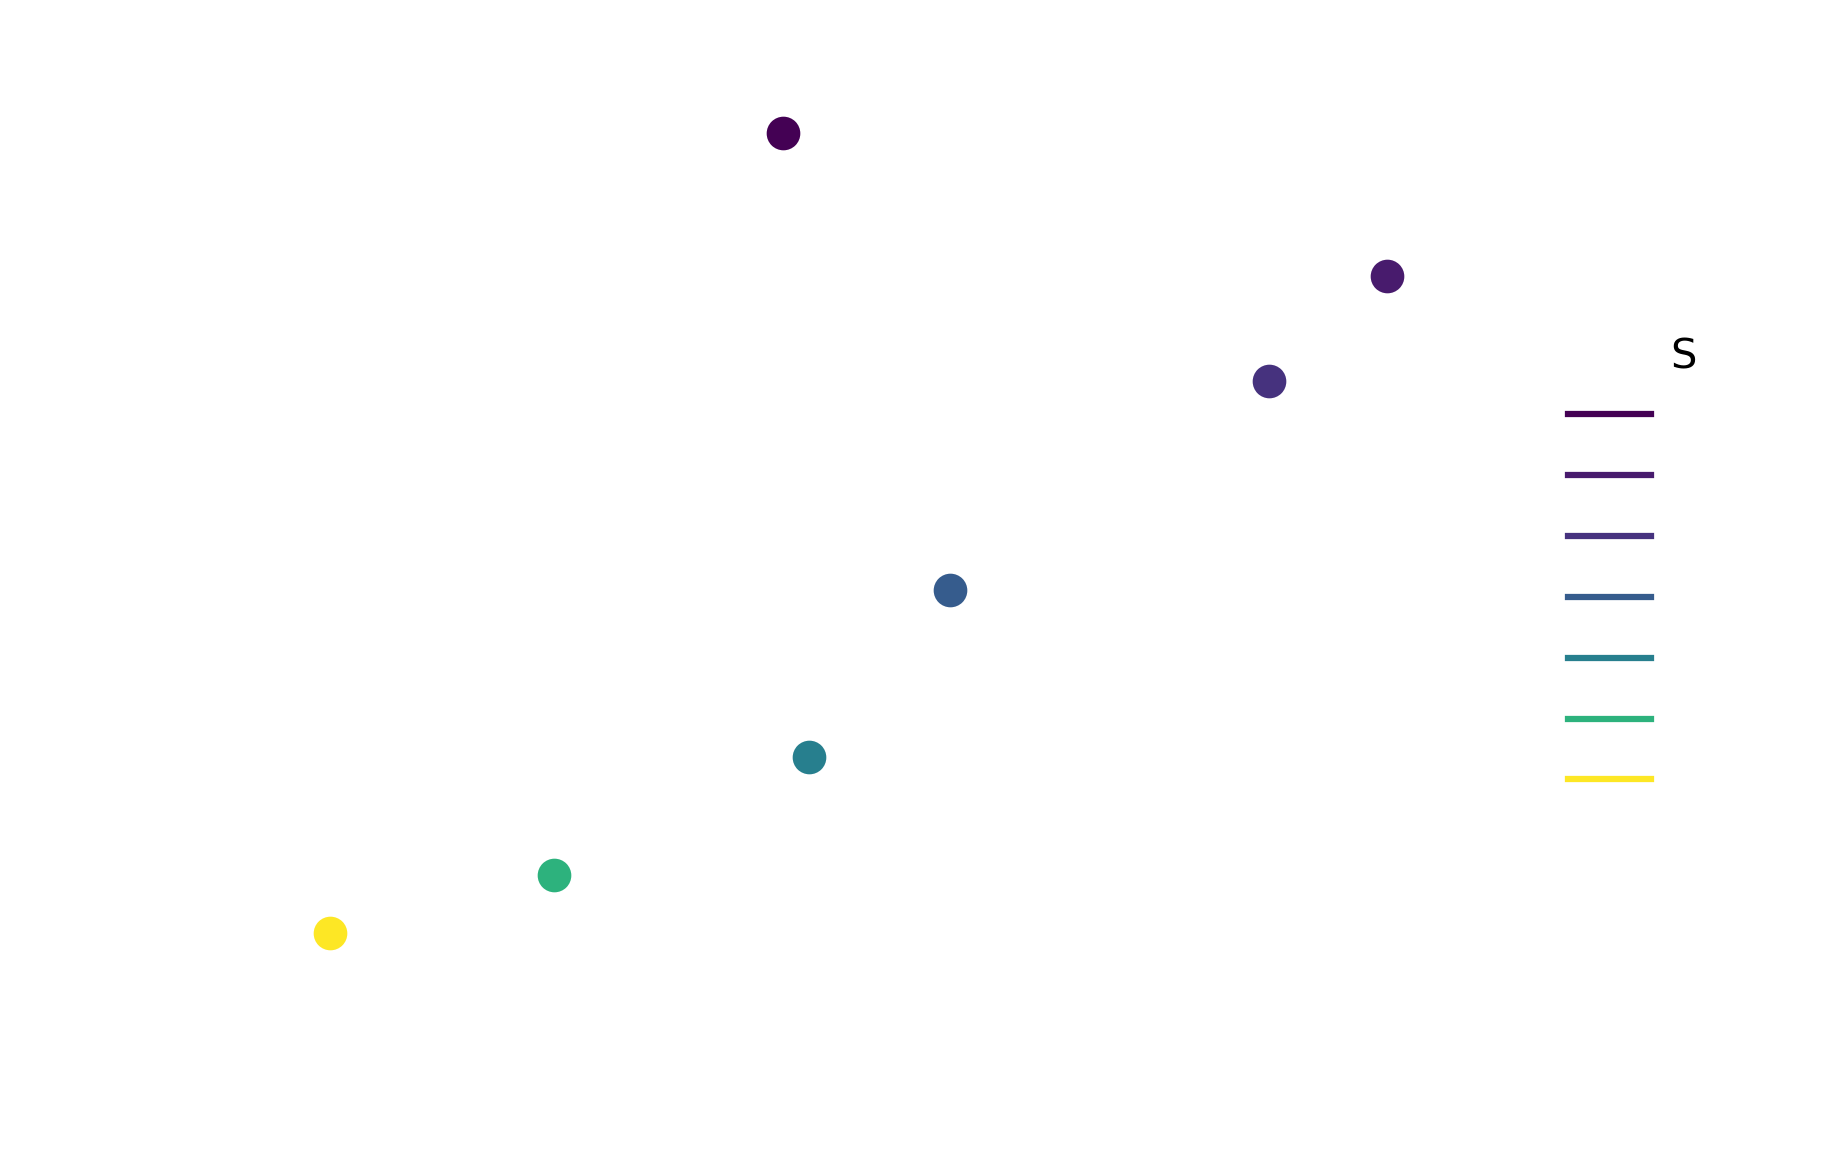

In [121]:
# Learning trajectories across S
# 1) G vs I per S
# 2) G over epochs per S
# 3) I over epochs per S
# Final G vs I scatter (colored by S) for available sweeps
cmap = cm.get_cmap('viridis')
norm = plt.Normalize(min(S_values), max(S_values))

fig = plt.figure(figsize=(5,4), facecolor='none')
fig.patch.set_alpha(0)
ax = plt.gca()
for S, hist in S_histories.items():
    G = np.array(hist['similarity_scores'])
    I = np.array(hist['identification_scores'])
    plt.plot(G, I, color=cmap(norm(S)), label=f'S={S}')
plt.xlabel('G-score'); plt.ylabel('I-score'); plt.title('G vs I trajectories'); plt.legend()
# White axes/spines/ticks and transparent axes background
ax.set_facecolor('none')
for spine in ax.spines.values():
    spine.set_color('white')
ax.tick_params(colors='white')
leg = ax.legend()
for text in leg.get_texts():
    text.set_color('white')
leg.get_frame().set_facecolor('none')
leg.get_frame().set_edgecolor('white')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10,3), facecolor='none', dpi=300)
fig.patch.set_alpha(0)
for S, hist in S_histories.items():
    G = np.array(hist['similarity_scores'])
    I = np.array(hist['identification_scores'])
    axes[0].plot(G, color=cmap(norm(S)), label=f'S={S}')
    axes[1].plot(I, color=cmap(norm(S)), label=f'S={S}')
# Titles and labels in white
axes[0].set_title('G over epochs', color='white')
axes[0].set_xlabel('Epoch', color='white')
axes[0].set_ylabel('G', color='white')
axes[1].set_title('I over epochs', color='white')
axes[1].set_xlabel('Epoch', color='white')
axes[1].set_ylabel('I', color='white')
# White axes/spines/ticks and transparent axes background
for ax_sub in axes:
    ax_sub.set_facecolor('none')
    for spine in ax_sub.spines.values():
        spine.set_color('white')
    ax_sub.tick_params(colors='white')
    ax_sub.spines.right.set_visible(False)
    ax_sub.spines.top.set_visible(False)
    ax_sub.spines.left.set_position(('outward', 10))
    ax_sub.spines.bottom.set_position(('outward', 10))
# Single legend for entire figure, outside to the right
handles, labels = axes[0].get_legend_handles_labels()
leg = fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, title='S')
leg.get_title().set_color('white')
for text in leg.get_texts():
    text.set_color('white')
# Leave space on the right for the legend
fig.subplots_adjust(right=0.99)
plt.tight_layout(rect=(0, 0, 0.99, 1)); plt.show()

# Final G vs I scatter (colored by S) for available sweeps
fig = plt.figure(figsize=(5,4), facecolor='none', dpi=300)
fig.patch.set_alpha(0)
ax = plt.gca()
for S, hist in S_histories.items():
    G = hist['similarity_scores'][-1] #final G score
    I = hist['identification_scores'][-1] #final I score
    ax.scatter(G, I, label=f'S={S}', color=cmap(norm(S)), s=50 )
ax.set_xlabel('G-score', color='white'); ax.set_ylabel('I-score', color='white'); ax.set_title('G vs I scatter', color='white')
# White axes/spines/ticks and transparent axes background
ax.set_facecolor('none')
for spine in ax.spines.values():
    spine.set_color('white')
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.spines.left.set_position(('outward', 10))
ax.spines.bottom.set_position(('outward', 10))
ax.tick_params(colors='white')
leg = fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, title='S')
leg.get_frame().set_facecolor('none')
for text in leg.get_texts():
    text.set_color('white')
leg.set_bbox_to_anchor((1.02, 0.5))
plt.tight_layout(); plt.show()


## One-slot sweep: effect of vocab size V
We fix the number of slots to 1 and vary the per-slot vocab size V from 8 to 20 (ring metric). We train a short run per V, record histories, and plot:
- Final G/I vs V
- G vs I trajectories
- G and I over epochs per V


In [ ]:
def make_ring(V: int) -> torch.Tensor:
    idx = torch.arange(V).unsqueeze(0)
    circ = torch.minimum((idx - idx.T).abs(), V - (idx - idx.T).abs())
    return (circ / circ.max()).to(torch.float32)

V_values = list(range(8, 21))  # 8..20 inclusive
sequence_len = 3
batch_size = 64
num_samples = 1024
feature_dim = 16
agg = 'min'

V_histories = {}
final_G, final_I = [], []
for V in V_values:
    vocab_sizes = (V,)
    slot_metric_matrices = (make_ring(V),)
    gen_cfg = CompositionalDataGeneratorConfig(
        num_slots=1,
        vocab_sizes=vocab_sizes,
        sequence_len=sequence_len,
        batch_size=batch_size,
        slot_metric_matrices=slot_metric_matrices,
        seed=SEED,
        num_samples=num_samples,
        distance_aggregation=agg,
    )
    data_gen_V = CompositionalDataGenerator(gen_cfg)

    model_cfg_V = CompositionalModelConfig(
        input_dim=sum(vocab_sizes),
        feature_dim=feature_dim,
        sequence_len=sequence_len,
        vocab_sizes=vocab_sizes,
    )
    model_V = CompositionalModel(model_cfg_V)

    trainer_cfg_V = TrainerConfig()
    trainer_cfg_V.num_epochs = 250
    trainer_cfg_V.learning_rate = 1e-3
    trainer_cfg_V.patience = 10
    trainer_cfg_V.min_lr = 1e-6
    if not hasattr(trainer_cfg_V, 'lambda_sim'):
        trainer_cfg_V.lambda_sim = 1.0
    if not hasattr(trainer_cfg_V, 'lambda_rec'):
        trainer_cfg_V.lambda_rec = 1.0

    data_gen_V.config.device = trainer_cfg_V.device

    trainer_V = MillerTrainer(model_V, data_gen_V, trainer_cfg_V)
    history_V = trainer_V.train(verbose=False, printevery=50)

    V_histories[V] = history_V
    final_G.append(history_V['similarity_scores'][-1])
    final_I.append(history_V['identification_scores'][-1])

In [ ]:

cmap = cm.get_cmap('viridis')
norm = plt.Normalize(min(V_values), max(V_values))

# Final scores vs V (colored scatter)
plt.figure(figsize=(6,3))
plt.scatter(V_values, final_G, c=V_values, cmap=cmap, norm=norm, label='G-score', marker='o')
plt.scatter(V_values, final_I, c=V_values, cmap=cmap, norm=norm, label='I-score', marker='s', alpha=0.8)
plt.xlabel('Vocab size V'); plt.ylabel('Final val score'); plt.title('Performance vs V (S=1, viridis)')
cbar = plt.colorbar()
cbar.set_label('V')
plt.legend(); plt.tight_layout(); plt.show()

# G vs I trajectories per V
plt.figure(figsize=(5,4))
for V, hist in V_histories.items():
    G = np.array(hist['similarity_scores'])
    I = np.array(hist['identification_scores'])
    plt.plot(G, I, color=cmap(norm(V)), label=f'V={V}')
plt.xlabel('G-score'); plt.ylabel('I-score'); plt.title('G vs I trajectories (S=1, viridis)')
plt.legend(ncol=2); plt.tight_layout(); plt.show()

# G and I over epochs per V
fig, axes = plt.subplots(1, 2, figsize=(10,3))
for V, hist in V_histories.items():
    axes[0].plot(hist['similarity_scores'], color=cmap(norm(V)), label=f'V={V}')
    axes[1].plot(hist['identification_scores'], color=cmap(norm(V)), label=f'V={V}')
axes[0].set_title('G over epochs (S=1)'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('G')
axes[1].set_title('I over epochs (S=1)'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('I')
axes[0].legend(ncol=2); axes[1].legend(ncol=2)
plt.tight_layout(); plt.show()


## Two-slot sweep: vary vocab size V
We now fix S=2 and sweep a shared per-slot vocab size V (e.g., 8..20) to see how performance and trajectories change with two features.


In [ ]:
# Two-slot V sweep (V same on both slots)
V2_values = list(range(8, 21))
S = 2
sequence_len = 3
batch_size = 64
num_samples = 1024
feature_dim = 16
agg = 'min'

V2_histories = {}
final_G2, final_I2 = [], []
for V in V2_values:
    vocab_sizes = (V, V)
    slot_metric_matrices = (make_ring(V), make_ring(V))
    gen_cfg = CompositionalDataGeneratorConfig(
        num_slots=S,
        vocab_sizes=vocab_sizes,
        sequence_len=sequence_len,
        batch_size=batch_size,
        slot_metric_matrices=slot_metric_matrices,
        seed=SEED,
        num_samples=num_samples,
        distance_aggregation=agg,
    )
    data_gen_V2 = CompositionalDataGenerator(gen_cfg)

    model_cfg_V2 = CompositionalModelConfig(
        input_dim=sum(vocab_sizes),
        feature_dim=feature_dim,
        sequence_len=sequence_len,
        vocab_sizes=vocab_sizes,
    )
    model_V2 = CompositionalModel(model_cfg_V2)

    trainer_cfg_V2 = TrainerConfig()
    trainer_cfg_V2.num_epochs = 250
    trainer_cfg_V2.learning_rate = 1e-3
    trainer_cfg_V2.patience = 10
    trainer_cfg_V2.min_lr = 1e-6
    if not hasattr(trainer_cfg_V2, 'lambda_sim'):
        trainer_cfg_V2.lambda_sim = 1.0
    if not hasattr(trainer_cfg_V2, 'lambda_rec'):
        trainer_cfg_V2.lambda_rec = 1.0

    data_gen_V2.config.device = trainer_cfg_V2.device

    trainer_V2 = MillerTrainer(model_V2, data_gen_V2, trainer_cfg_V2)
    history_V2 = trainer_V2.train(verbose=False, printevery=50)

    V2_histories[V] = history_V2
    final_G2.append(history_V2['similarity_scores'][-1])
    final_I2.append(history_V2['identification_scores'][-1])

# Plots with viridis colormap
cmap = cm.get_cmap('viridis'); norm = plt.Normalize(min(V2_values), max(V2_values))
plt.figure(figsize=(6,3))
plt.scatter(V2_values, final_G2, c=V2_values, cmap=cmap, norm=norm, label='G-score', marker='o')
plt.scatter(V2_values, final_I2, c=V2_values, cmap=cmap, norm=norm, label='I-score', marker='s', alpha=0.8)
plt.xlabel('Vocab size V per slot'); plt.ylabel('Final val score'); plt.title('Performance vs V (S=2, viridis)')
cbar = plt.colorbar(); cbar.set_label('V')
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(5,4))
for V, hist in V2_histories.items():
    G = np.array(hist['similarity_scores'])
    I = np.array(hist['identification_scores'])
    plt.plot(G, I, color=cmap(norm(V)), label=f'V={V}')
plt.xlabel('G-score'); plt.ylabel('I-score'); plt.title('G vs I trajectories (S=2, viridis)')
plt.legend(ncol=2); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10,3))
for V, hist in V2_histories.items():
    axes[0].plot(hist['similarity_scores'], color=cmap(norm(V)), label=f'V={V}')
    axes[1].plot(hist['identification_scores'], color=cmap(norm(V)), label=f'V={V}')
axes[0].set_title('G over epochs (S=2)'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('G')
axes[1].set_title('I over epochs (S=2)'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('I')
axes[0].legend(ncol=2); axes[1].legend(ncol=2)
plt.tight_layout(); plt.show()


## Three-slot sweep: vary vocab size V
We fix S=3 and sweep a shared per-slot vocab size V from 8 to 20.


In [ ]:
# Three-slot V sweep (V same on all three slots)
V3_values = list(range(8, 21))
S = 3
sequence_len = 3
batch_size = 64
num_samples = 1024
feature_dim = 16
agg = 'min'

V3_histories = {}
final_G3, final_I3 = [], []
for V in V3_values:
    vocab_sizes = (V, V, V)
    slot_metric_matrices = (make_ring(V), make_ring(V), make_ring(V))
    gen_cfg = CompositionalDataGeneratorConfig(
        num_slots=S,
        vocab_sizes=vocab_sizes,
        sequence_len=sequence_len,
        batch_size=batch_size,
        slot_metric_matrices=slot_metric_matrices,
        seed=SEED,
        num_samples=num_samples,
        distance_aggregation=agg,
    )
    data_gen_V3 = CompositionalDataGenerator(gen_cfg)

    model_cfg_V3 = CompositionalModelConfig(
        input_dim=sum(vocab_sizes),
        feature_dim=feature_dim,
        sequence_len=sequence_len,
        vocab_sizes=vocab_sizes,
    )
    model_V3 = CompositionalModel(model_cfg_V3)

    trainer_cfg_V3 = TrainerConfig()
    trainer_cfg_V3.num_epochs = 250
    trainer_cfg_V3.learning_rate = 1e-3
    trainer_cfg_V3.patience = 10
    trainer_cfg_V3.min_lr = 1e-6
    if not hasattr(trainer_cfg_V3, 'lambda_sim'):
        trainer_cfg_V3.lambda_sim = 1.0
    if not hasattr(trainer_cfg_V3, 'lambda_rec'):
        trainer_cfg_V3.lambda_rec = 1.0

    data_gen_V3.config.device = trainer_cfg_V3.device

    trainer_V3 = MillerTrainer(model_V3, data_gen_V3, trainer_cfg_V3)
    history_V3 = trainer_V3.train(verbose=False, printevery=50)

    V3_histories[V] = history_V3
    final_G3.append(history_V3['similarity_scores'][-1])
    final_I3.append(history_V3['identification_scores'][-1])

# Plots with viridis colormap
cmap = cm.get_cmap('viridis'); norm = plt.Normalize(min(V3_values), max(V3_values))
plt.figure(figsize=(6,3))
plt.scatter(V3_values, final_G3, c=V3_values, cmap=cmap, norm=norm, label='G-score', marker='o')
plt.scatter(V3_values, final_I3, c=V3_values, cmap=cmap, norm=norm, label='I-score', marker='s', alpha=0.8)
plt.xlabel('Vocab size V per slot'); plt.ylabel('Final val score'); plt.title('Performance vs V (S=3, viridis)')
cbar = plt.colorbar(); cbar.set_label('V')
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(5,4))
for V, hist in V3_histories.items():
    G = np.array(hist['similarity_scores'])
    I = np.array(hist['identification_scores'])
    plt.plot(G, I, color=cmap(norm(V)), label=f'V={V}')
plt.xlabel('G-score'); plt.ylabel('I-score'); plt.title('G vs I trajectories (S=3, viridis)')
plt.legend(ncol=2); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10,3))
for V, hist in V3_histories.items():
    axes[0].plot(hist['similarity_scores'], color=cmap(norm(V)), label=f'V={V}')
    axes[1].plot(hist['identification_scores'], color=cmap(norm(V)), label=f'V={V}')
axes[0].set_title('G over epochs (S=3)'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('G')
axes[1].set_title('I over epochs (S=3)'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('I')
axes[0].legend(ncol=2); axes[1].legend(ncol=2)
plt.tight_layout(); plt.show()


## Five-slot sweep: vary vocab size V
All slots use ring distance; we sweep V=8..20 and plot final scores, G–I, and per-epoch curves.


In [ ]:
# S=5 V sweep
V5_values = list(range(8, 31))
S = 5
sequence_len = 3
batch_size = 64
num_samples = 1024
feature_dim = 16
agg = 'min'

V5_histories = {}
final_G5, final_I5 = [], []
for V in V5_values:
    vocab_sizes = tuple([V]*S)
    slot_metric_matrices = tuple([make_ring(V) for _ in range(S)])
    gen_cfg = CompositionalDataGeneratorConfig(
        num_slots=S,
        vocab_sizes=vocab_sizes,
        sequence_len=sequence_len,
        batch_size=batch_size,
        slot_metric_matrices=slot_metric_matrices,
        seed=SEED,
        num_samples=num_samples,
        distance_aggregation=agg,
    )
    data_gen_V5 = CompositionalDataGenerator(gen_cfg)

    model_cfg_V5 = CompositionalModelConfig(
        input_dim=sum(vocab_sizes),
        feature_dim=feature_dim,
        sequence_len=sequence_len,
        vocab_sizes=vocab_sizes,
    )
    model_V5 = CompositionalModel(model_cfg_V5)

    trainer_cfg_V5 = TrainerConfig()
    trainer_cfg_V5.num_epochs = 250
    trainer_cfg_V5.learning_rate = 1e-3
    trainer_cfg_V5.patience = 10
    trainer_cfg_V5.min_lr = 1e-6
    if not hasattr(trainer_cfg_V5, 'lambda_sim'):
        trainer_cfg_V5.lambda_sim = 1.0
    if not hasattr(trainer_cfg_V5, 'lambda_rec'):
        trainer_cfg_V5.lambda_rec = 1.0

    data_gen_V5.config.device = trainer_cfg_V5.device

    trainer_V5 = MillerTrainer(model_V5, data_gen_V5, trainer_cfg_V5)
    history_V5 = trainer_V5.train(verbose=False, printevery=50)

    V5_histories[V] = history_V5
    final_G5.append(history_V5['similarity_scores'][-1])
    final_I5.append(history_V5['identification_scores'][-1])

# Plots with viridis colormap
cmap = cm.get_cmap('viridis'); norm = plt.Normalize(min(V5_values), max(V5_values))
plt.figure(figsize=(6,3))
plt.scatter(V5_values, final_G5, c=V5_values, cmap=cmap, norm=norm, label='G-score', marker='o')
plt.scatter(V5_values, final_I5, c=V5_values, cmap=cmap, norm=norm, label='I-score', marker='s', alpha=0.8)
plt.xlabel('Vocab size V per slot'); plt.ylabel('Final val score'); plt.title('Performance vs V (S=5, viridis)')
cbar = plt.colorbar(); cbar.set_label('V')
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(5,4))
for V, hist in V5_histories.items():
    G = np.array(hist['similarity_scores'])
    I = np.array(hist['identification_scores'])
    plt.plot(G, I, color=cmap(norm(V)), label=f'V={V}')
plt.xlabel('G-score'); plt.ylabel('I-score'); plt.title('G vs I trajectories (S=5, viridis)')
plt.legend(ncol=2); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10,3))
for V, hist in V5_histories.items():
    axes[0].plot(hist['similarity_scores'], color=cmap(norm(V)), label=f'V={V}')
    axes[1].plot(hist['identification_scores'], color=cmap(norm(V)), label=f'V={V}')
axes[0].set_title('G over epochs (S=5)'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('G')
axes[1].set_title('I over epochs (S=5)'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('I')
axes[0].legend(ncol=2); axes[1].legend(ncol=2)
plt.tight_layout(); plt.show()


## Seven-slot sweep and Ten-slot sweep
We repeat the V sweep for S=7 and S=10.


In [ ]:
def sweep_slots(S: int, V_values):
    histories = {}
    final_G, final_I = [], []
    for V in V_values:
        vocab_sizes = tuple([V]*S)
        slot_metric_matrices = tuple([make_ring(V) for _ in range(S)])
        gen_cfg = CompositionalDataGeneratorConfig(
            num_slots=S,
            vocab_sizes=vocab_sizes,
            sequence_len=3,
            batch_size=64,
            slot_metric_matrices=slot_metric_matrices,
            seed=SEED,
            num_samples=1024,
            distance_aggregation='min',
        )
        data_gen = CompositionalDataGenerator(gen_cfg)

        model_cfg = CompositionalModelConfig(
            input_dim=sum(vocab_sizes),
            feature_dim=16,
            sequence_len=3,
            vocab_sizes=vocab_sizes,
        )
        model = CompositionalModel(model_cfg)

        tcfg = TrainerConfig()
        tcfg.num_epochs = 250
        tcfg.learning_rate = 1e-3
        tcfg.patience = 10
        tcfg.min_lr = 1e-6
        if not hasattr(tcfg, 'lambda_sim'):
            tcfg.lambda_sim = 1.0
        if not hasattr(tcfg, 'lambda_rec'):
            tcfg.lambda_rec = 1.0

        data_gen.config.device = tcfg.device

        trainer = MillerTrainer(model, data_gen, tcfg)
        hist = trainer.train(verbose=False, printevery=50)

        histories[V] = hist
        final_G.append(hist['similarity_scores'][-1])
        final_I.append(hist['identification_scores'][-1])
    return histories, final_G, final_I

# S=7
V7_values = list(range(8, 41))
H7, G7, I7 = sweep_slots(7, V7_values)

cmap = cm.get_cmap('viridis'); norm7 = plt.Normalize(min(V7_values), max(V7_values))
plt.figure(figsize=(6,3))
plt.scatter(V7_values, G7, c=V7_values, cmap=cmap, norm=norm7, label='G-score', marker='o')
plt.scatter(V7_values, I7, c=V7_values, cmap=cmap, norm=norm7, label='I-score', marker='s', alpha=0.8)
plt.xlabel('Vocab size V per slot'); plt.ylabel('Final val score'); plt.title('Performance vs V (S=7, viridis)')
cbar = plt.colorbar(); cbar.set_label('V')
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(5,4))
for V, hist in H7.items():
    G = np.array(hist['similarity_scores'])
    I = np.array(hist['identification_scores'])
    plt.plot(G, I, color=cmap(norm7(V)), label=f'V={V}')
plt.xlabel('G-score'); plt.ylabel('I-score'); plt.title('G vs I trajectories (S=7, viridis)')
plt.legend(ncol=2); plt.tight_layout(); plt.show()

# S=10
V10_values = list(range(8, 51))
H10, G10, I10 = sweep_slots(10, V10_values)

norm10 = plt.Normalize(min(V10_values), max(V10_values))
plt.figure(figsize=(6,3))
plt.scatter(V10_values, G10, c=V10_values, cmap=cmap, norm=norm10, label='G-score', marker='o')
plt.scatter(V10_values, I10, c=V10_values, cmap=cmap, norm=norm10, label='I-score', marker='s', alpha=0.8)
plt.xlabel('Vocab size V per slot'); plt.ylabel('Final val score'); plt.title('Performance vs V (S=10, viridis)')
cbar = plt.colorbar(); cbar.set_label('V')
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(5,4))
for V, hist in H10.items():
    G = np.array(hist['similarity_scores'])
    I = np.array(hist['identification_scores'])
    plt.plot(G, I, color=cmap(norm10(V)), label=f'V={V}')
plt.xlabel('G-score'); plt.ylabel('I-score'); plt.title('G vs I trajectories (S=10, viridis)')
plt.legend(ncol=2); plt.tight_layout(); plt.show()


In [ ]:
# Final G vs I scatter (colored by V) for available sweeps
from matplotlib import cm
cmap = cm.get_cmap('viridis')

sections = []
if 'final_G' in globals() and 'final_I' in globals() and 'V_values' in globals():
    sections.append(('S=1', V_values, final_G, final_I))
if 'final_G2' in globals() and 'final_I2' in globals() and 'V2_values' in globals():
    sections.append(('S=2', V2_values, final_G2, final_I2))
if 'final_G3' in globals() and 'final_I3' in globals() and 'V3_values' in globals():
    sections.append(('S=3', V3_values, final_G3, final_I3))
if 'final_G5' in globals() and 'final_I5' in globals() and 'V5_values' in globals():
    sections.append(('S=5', V5_values, final_G5, final_I5))
if 'G7' in globals() and 'I7' in globals() and 'V7_values' in globals():
    sections.append(('S=7', V7_values, G7, I7))
if 'G10' in globals() and 'I10' in globals() and 'V10_values' in globals():
    sections.append(('S=10', V10_values, G10, I10))

# Filter to only sections with matching, non-empty lengths
filtered = []
for title, Vv, Gv, Iv in sections:
    Vv_arr = list(Vv)
    Gv_arr = list(Gv)
    Iv_arr = list(Iv)
    if len(Vv_arr) > 0 and len(Gv_arr) == len(Vv_arr) and len(Iv_arr) == len(Vv_arr):
        filtered.append((title, Vv_arr, Gv_arr, Iv_arr))

n = len(filtered)
if n == 0:
    print('No completed sweeps found. Run the sweep cells first.')
else:
    cols = 2
    rows = max(1, (n + cols - 1) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 3*rows))
    axes = np.array(axes).reshape(rows, cols)

    for idx, (title, Vv, Gv, Iv) in enumerate(filtered):
        r, c = divmod(idx, cols)
        ax = axes[r, c]
        norm = plt.Normalize(min(Vv), max(Vv))
        sc = ax.scatter(Gv, Iv, c=Vv, cmap=cmap, norm=norm)
        ax.set_xlabel('Final G'); ax.set_ylabel('Final I'); ax.set_title(f'Final G vs I ({title})')
        cbar = fig.colorbar(sc, ax=ax); cbar.set_label('V')

    # Hide any empty subplots
    for i in range(n, rows*cols):
        r, c = divmod(i, cols)
        axes[r, c].axis('off')

    plt.tight_layout(); plt.show()
